# Prediction Models and Delay Prediction

This notebook uses the cleaned dataset for:
1. Lead time regression models
2. Delay classification and single-order delay prediction

In [119]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [120]:
file_path = "/home/pratyush_device/Documents/college/AIML lab/Project/customer_cleaned.csv"
df = pd.read_csv(file_path)

print("Loaded shape:", df.shape)
df.head()

Loaded shape: (750, 26)


,acquisition_cost_usd,order_value_usd,satisfaction_score,support_tickets,lead_time_days,days_acq_to_order,days_order_to_payment,acquisition_date_year,acquisition_date_month,acquisition_date_dayofweek,...,market_segment_Asia-Pacific,market_segment_Europe,market_segment_Middle East,market_segment_North America,supplier_id_SUP-B,supplier_id_SUP-C,supplier_id_SUP-D,supplier_id_SUP-E,supplier_id_SUP-F,supplier_id_SUP-G
0,850,12500,4,1,14,10,34,2024,1,4,...,False,False,False,True,False,False,False,False,False,False
1,920,8500,5,0,16,12,38,2024,1,5,...,False,True,False,False,True,False,False,False,False,False
2,880,21000,4,2,15,13,41,2024,1,6,...,True,False,False,False,False,True,False,False,False,False
3,790,7500,3,1,13,14,37,2024,1,0,...,False,False,False,True,False,False,False,False,False,False
4,950,15000,5,0,12,16,40,2024,1,1,...,False,True,False,False,False,False,True,False,False,False


In [121]:
df.columns

Index(['acquisition_cost_usd', 'order_value_usd', 'satisfaction_score',
       'support_tickets', 'lead_time_days', 'days_acq_to_order',
       'days_order_to_payment', 'acquisition_date_year',
       'acquisition_date_month', 'acquisition_date_dayofweek',
       'order_date_year', 'order_date_month', 'order_date_dayofweek',
       'payment_date_year', 'payment_date_month', 'payment_date_dayofweek',
       'market_segment_Asia-Pacific', 'market_segment_Europe',
       'market_segment_Middle East', 'market_segment_North America',
       'supplier_id_SUP-B', 'supplier_id_SUP-C', 'supplier_id_SUP-D',
       'supplier_id_SUP-E', 'supplier_id_SUP-F', 'supplier_id_SUP-G'],
      dtype='object')

In [122]:
# Regression target
target_col = "lead_time_days"

if target_col not in df.columns:
    raise ValueError("lead_time_days column not found in cleaned dataset.")

# Convert all non-numeric predictors to numeric for model compatibility
X_reg_raw = df.drop(columns=[target_col])
X_reg = pd.get_dummies(X_reg_raw, drop_first=True)
y_reg = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=40
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Regression features:", X_reg.shape[1])

Regression features: 25


In [123]:
# Train regression models
reg_models = {
    "LinearRegression": LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(random_state=42),
    "SVR": SVR()
}

reg_results = []
for name, model in reg_models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    reg_results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "MSE": mean_squared_error(y_test, preds),
        "R2": r2_score(y_test, preds)
    })

reg_results_df = pd.DataFrame(reg_results).sort_values(by="R2", ascending=False)
reg_results_df

,Model,MAE,MSE,R2
1,RandomForestRegressor,0.236711,0.246481,0.929357
0,LinearRegression,0.436957,0.336066,0.903681
2,SVR,0.540652,0.609542,0.825301


In [124]:
# Create delay label from lead_time_days using 75th percentile threshold
delay_threshold = df[target_col].quantile(0.75)
df["delay"] = (df[target_col] > delay_threshold).astype(int)

print("Delay threshold:", delay_threshold)
print("Class distribution:")
print(df["delay"].value_counts(normalize=True))

Delay threshold: 16.0
Class distribution:
delay
0    0.877333
1    0.122667
Name: proportion, dtype: float64


In [ ]:
# Delay classification dataset
X_cls_raw = df.drop(columns=[target_col, "delay"])
X_cls = pd.get_dummies(X_cls_raw, drop_first=True)
y_cls = df["delay"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cls, y_cls, test_size = 0.35, random_state=42, stratify=y_cls
)

clf = RandomForestClas sifier(n_estimators=200, random_state=42)
clf.fit(Xc_train, yc_train)

yc_pred = clf.predict(Xc_test)
print("Classification features:", X_cls.shape[1])
print("Accuracy:", accuracy_score(yc_test, yc_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(yc_test, yc_pred))
print("\nClassification Report:")
print(classification_report(yc_test, yc_pred))

Classification features: 25
Accuracy: 1.0

Confusion Matrix:
[[231   0]
 [  0  32]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       231
           1       1.00      1.00      1.00        32

    accuracy                           1.00       263
   macro avg       1.00      1.00      1.00       263
weighted avg       1.00      1.00      1.00       263



In [126]:
def get_risk(prob):
    if prob > 0.7:
        return "High"
    elif prob > 0.4:
        return "Medium"
    return "Low"


def recommend_action(risk):
    if risk == "High":
        return "Expedite shipment or change supplier"
    if risk == "Medium":
        return "Monitor order closely"
    return "No action needed"


def predict_order(input_data):
    pred = clf.predict(input_data)
    prob = clf.predict_proba(input_data)[0][1]
    risk = get_risk(prob)
    action = recommend_action(risk)
    return {
        "Delay Prediction": int(pred),
        "Delay Probability": float(prob),
        "Risk Level": risk,
        "Recommended Action": action
    }

In [ ]:
# Example prediction for one order from test set
sample = Xc_test.iloc[[11]]
result = predict_order(sample)
result

/tmp/ipykernel_40742/2958160430.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "Delay Prediction": int(pred),


{'Delay Prediction': 1,
 'Delay Probability': 0.74,
 'Risk Level': 'High',
 'Recommended Action': 'Expedite shipment or change supplier'}

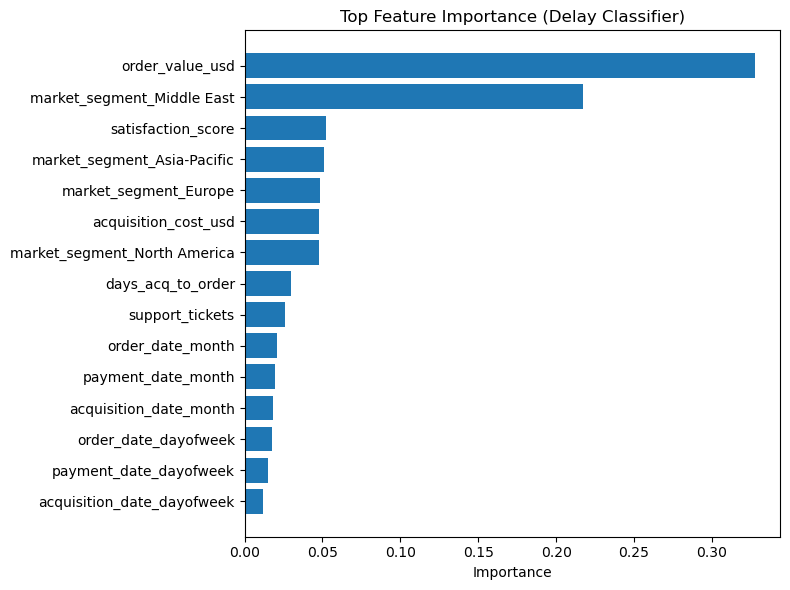

In [128]:
# Feature importance for delay classifier
import matplotlib.pyplot as plt

importances = pd.Series(clf.feature_importances_, index=X_cls.columns)
importances = importances.sort_values(ascending=True).tail(15)

plt.figure(figsize=(8, 6))
plt.barh(importances.index, importances.values)
plt.title("Top Feature Importance (Delay Classifier)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()